# Simulation study

In [1]:
import os 
import numpy as np
from joblib import Parallel,delayed
import matplotlib.pyplot as plt
from package import *
rc('text', usetex=True)
rc('font', family='serif')
sz = 32
n = 100
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'

### Convergence rate of paramaters

In simulation part, we will set repeat_time = 300.

In [2]:
repeat_time = 1 ### set 300
n = [200,400,600,800,1000]
v = [1,-0.5,0]

##### NURHM

In [3]:

N = lambda n: int(0.1*n*(np.log(n))**3)
m_lower = 2
m_upper = 8
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'NURHM')

----------
complete get edges: Num_Edges=2974, Num_Nodes = 200,m_lower = 2,m_upper = 8
[[78, 96, 101], [128, 82, 146, 88], [94, 187, 135, 189, 192, 128, 85], [11, 45, 190, 150, 69], [30, 87, 89, 61, 84, 48, 10], [115, 3, 1, 159], [91, 178, 196, 159, 184], [191, 99], [65, 174, 158], [100, 112], [198, 166, 99, 28, 47, 126, 132], [58, 54, 6], [175, 99, 66, 178, 180, 111], [28, 14, 97, 48, 80, 38], [80, 164, 111, 88, 81, 113, 160], [109, 69, 130, 150, 172, 6, 118], [160, 72], [186, 195], [142, 83], [159, 71], [125, 177, 105], [80, 103, 112, 73], [15, 159, 128, 37, 186, 75], [139, 161, 1], [140, 117], [142, 192, 183, 97], [158, 149, 50, 57, 88, 161, 111], [57, 176, 180, 134, 45, 46], [111, 42, 79, 76], [103, 150, 173], [83, 69], [6, 19, 159, 125, 74, 139], [53, 174, 15, 72], [132, 61], [88, 52], [154, 114, 99, 85], [140, 12, 141, 36], [192, 189, 92], [173, 198, 98, 48], [19, 126, 10, 115, 79, 25], [92, 89], [17, 58], [172, 72, 144, 26, 154, 138], [62, 87, 170, 101, 3], [34, 139, 6, 114, 167

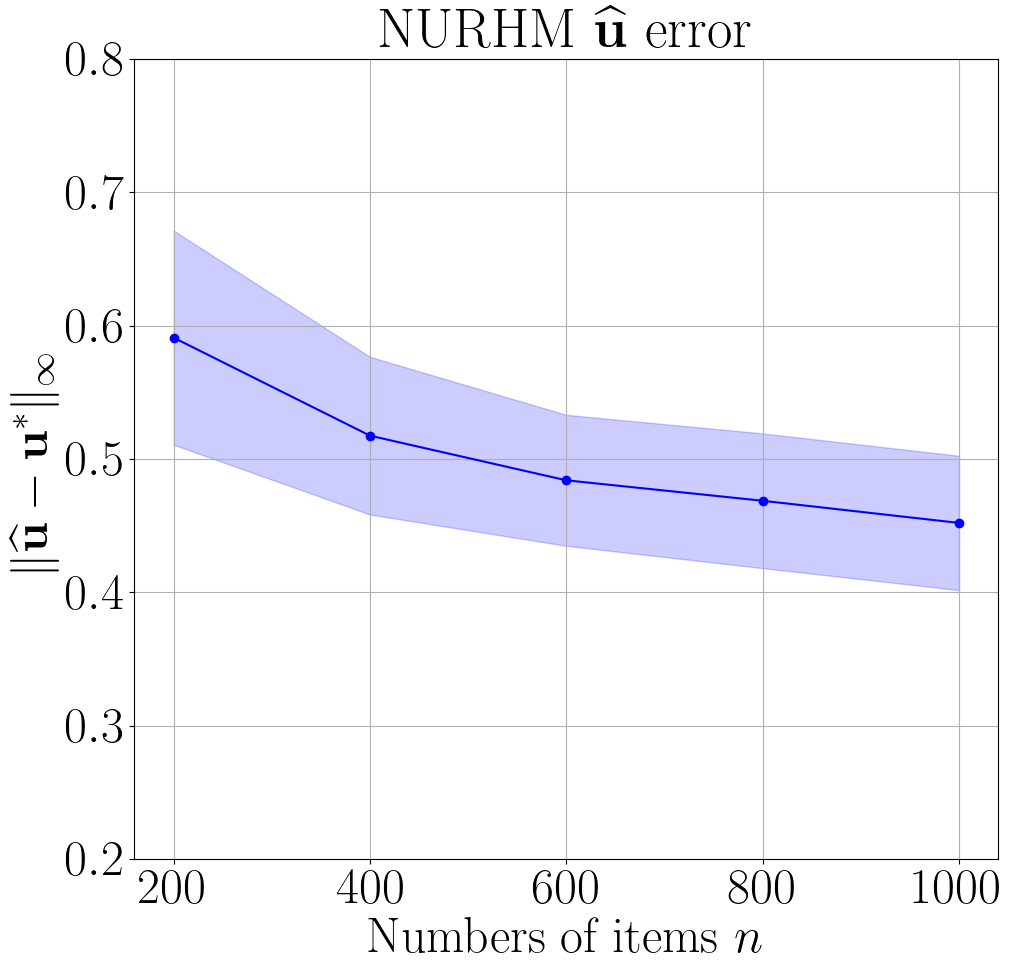

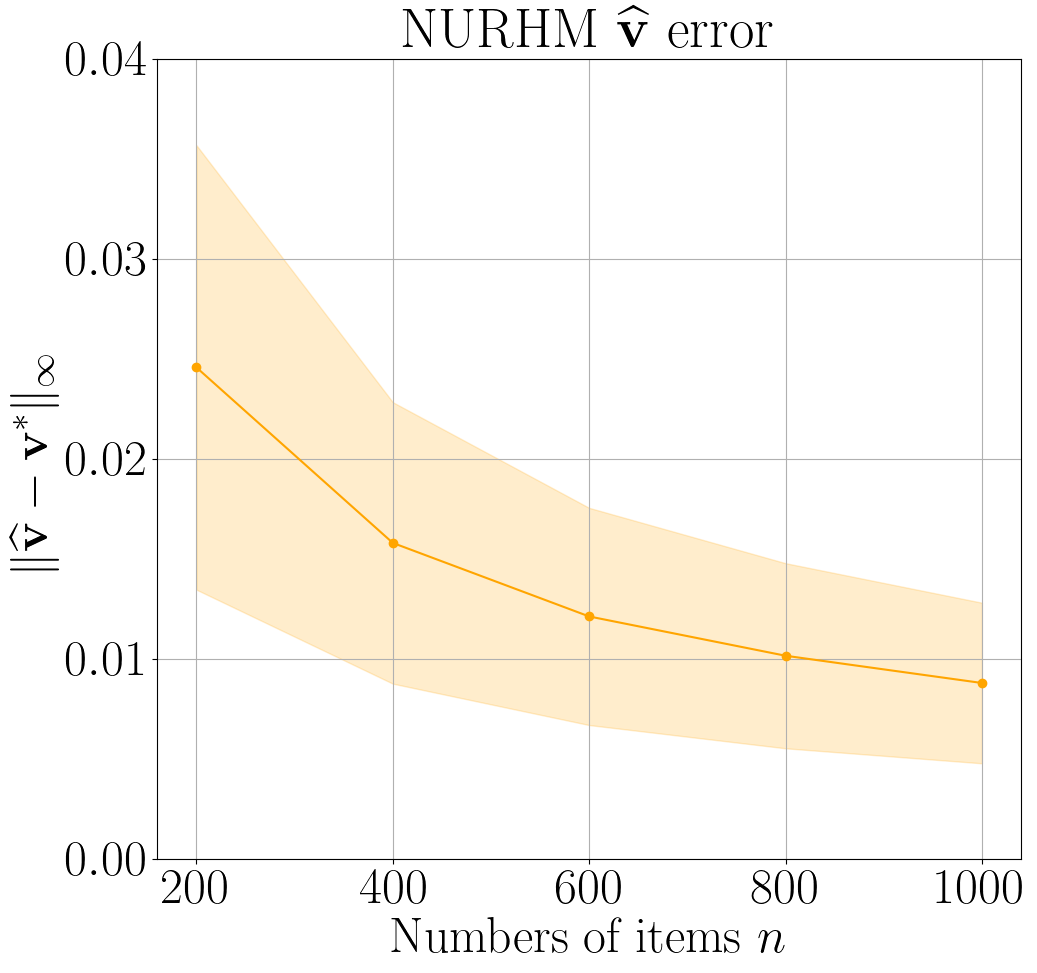

In [ ]:
basicfun.plot('NURHM',save_path)

##### HSBM

In [ ]:
N = lambda n: int(0.07*n**2)
m_lower = 5
m_upper = 6
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'HSBM')

----------
complete get edges: Num_Edges=2800, Num_Nodes = 200,m_lower = 5,m_upper = 5
[[83, 79, 88, 125, 117], [27, 90, 100, 157, 108], [101, 98, 93, 106, 144], [132, 190, 67, 96, 121], [161, 171, 69, 160, 141], [159, 80, 174, 128, 75], [91, 79, 143, 73, 96], [182, 183, 148, 161, 130], [89, 192, 128, 180, 98], [77, 71, 90, 97, 160], [78, 131, 117, 142, 80], [86, 153, 99, 173, 162], [24, 64, 63, 54, 29], [137, 110, 81, 181, 190], [197, 107, 189, 133, 191], [115, 148, 153, 149, 194], [170, 176, 165, 198, 189], [115, 156, 79, 166, 180], [44, 0, 43, 50, 25], [183, 128, 96, 164, 125], [109, 164, 72, 100, 186], [47, 56, 19, 18, 49], [50, 17, 21, 48, 2], [43, 29, 27, 47, 23], [142, 156, 115, 163, 85], [119, 72, 166, 120, 186], [122, 163, 66, 93, 169], [159, 152, 99, 143, 95], [48, 95, 111, 84, 60], [11, 12, 13, 59, 9], [180, 198, 90, 137, 178], [167, 197, 126, 96, 119], [128, 163, 102, 192, 124], [123, 177, 149, 116, 117], [82, 177, 170, 168, 162], [85, 191, 99, 132, 184], [136, 180, 173, 14

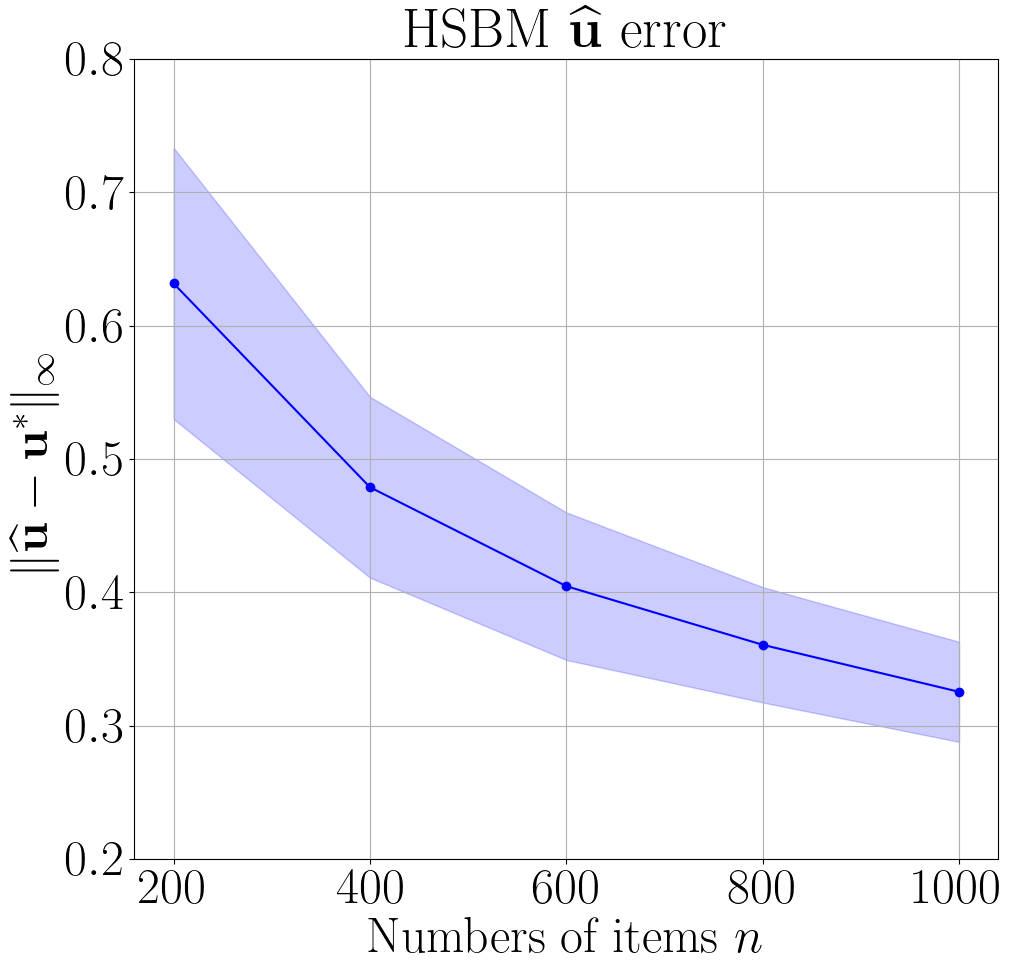

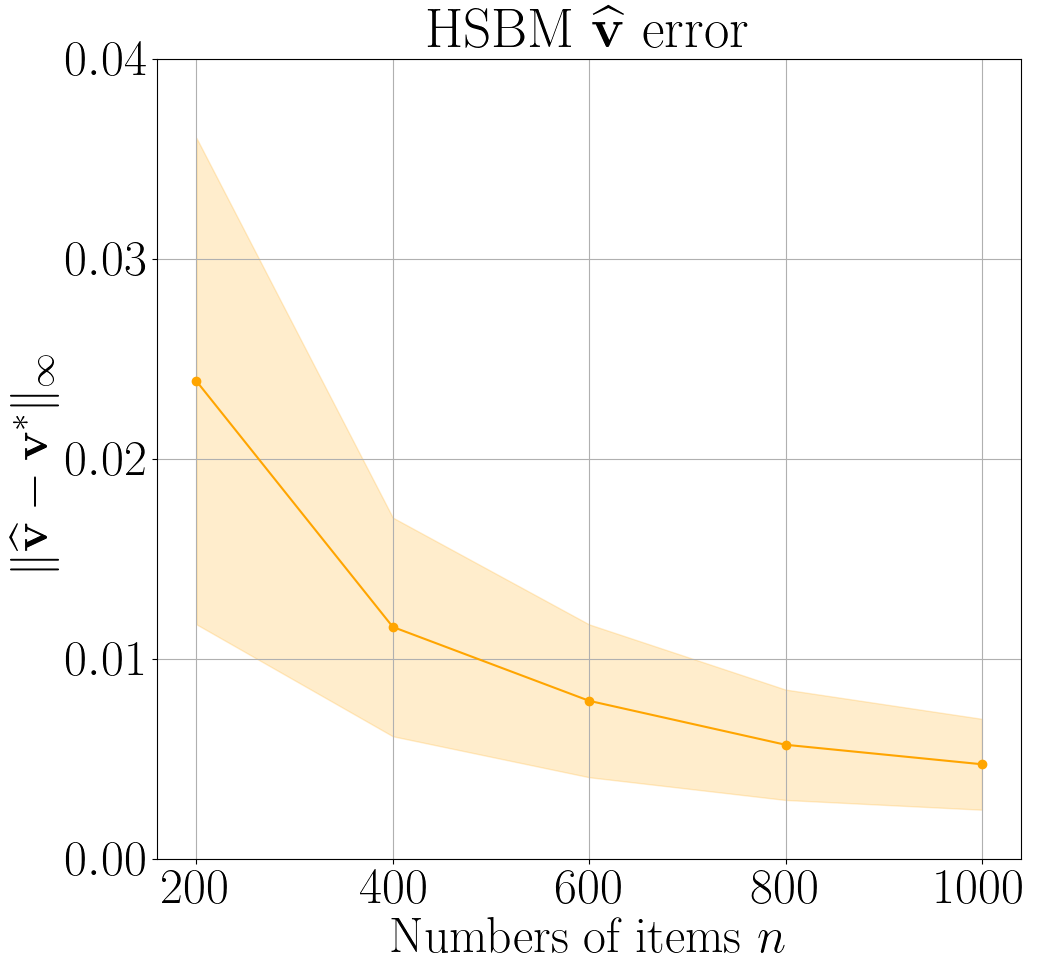

In [ ]:
basicfun.plot('HSBM',save_path)

### Convergence rate of alternating maximization algorithm

In [71]:
n = 200
N = lambda n: int(n*(n-1)/2)
v = [1]*200
d = len(v)
m_lower = 2
m_upper = 3
H = generator.MultipleComparison(n,N,v,m_lower=m_lower,m_upper=m_upper)

complete get edges: Num_Edges=19900, Num_Nodes = 200,m_lower = 2,m_upper = 3


In [72]:
from decimal import Decimal, getcontext

# 设置精度
getcontext().prec = 32
U = [np.zeros(n)]
V = [np.zeros(d)]
UU,VV = [],[]
for i in range(3):
    U = MM_pair(H.T,H.X,V[-1],n,utr=U[-1],I=100)
    V = Newton_pair(H.T,H.X,U[-1],d,vtr=V[-1],I=100)
    U_error = [np.linalg.norm(uu-U[-1]) for uu in U[:-1]]
    V_error = [np.linalg.norm(vv-V[-1]) for vv in V[:-1]]
    #UU.append(U_error_ratio)
    #VV.append(V_error_ratio)
    UU.append(U_error)
    VV.append(V_error)

In [74]:
VV[-1]

[0.6709122890657611,
 0.04365082164542074,
 0.00017434769654947965,
 2.8066103765164952e-09,
 3.1714313080323688e-15,
 2.7644330375917142e-15,
 2.5799251709695548e-15,
 3.076740298213702e-15,
 3.060673659425244e-15,
 2.5989654674417885e-15,
 3.2709212810858e-15,
 2.9624445261614194e-15,
 2.8780270159990897e-15,
 3.0201331455116262e-15,
 2.9624445261614194e-15,
 2.8435583831733384e-15,
 2.9036099814798757e-15,
 2.799875933971683e-15,
 2.9624445261614194e-15,
 3.0282846668030173e-15,
 3.0687174936894776e-15,
 2.9955454923751383e-15,
 3.011959563148489e-15,
 2.886579864025407e-15,
 2.9873046363423827e-15,
 3.2177320244274195e-15,
 3.6955587428207345e-15,
 2.6921477609369894e-15,
 2.9873046363423827e-15,
 2.589462819655575e-15,
 2.8780270159990897e-15,
 3.052608629176561e-15,
 2.7555010819726127e-15,
 2.7910574051884874e-15,
 2.8522145930998398e-15,
 2.8951074449790722e-15,
 2.6459668429208404e-15,
 2.7012892057857038e-15,
 2.8780270159990897e-15,
 2.817430187029739e-15,
 2.920540795418237

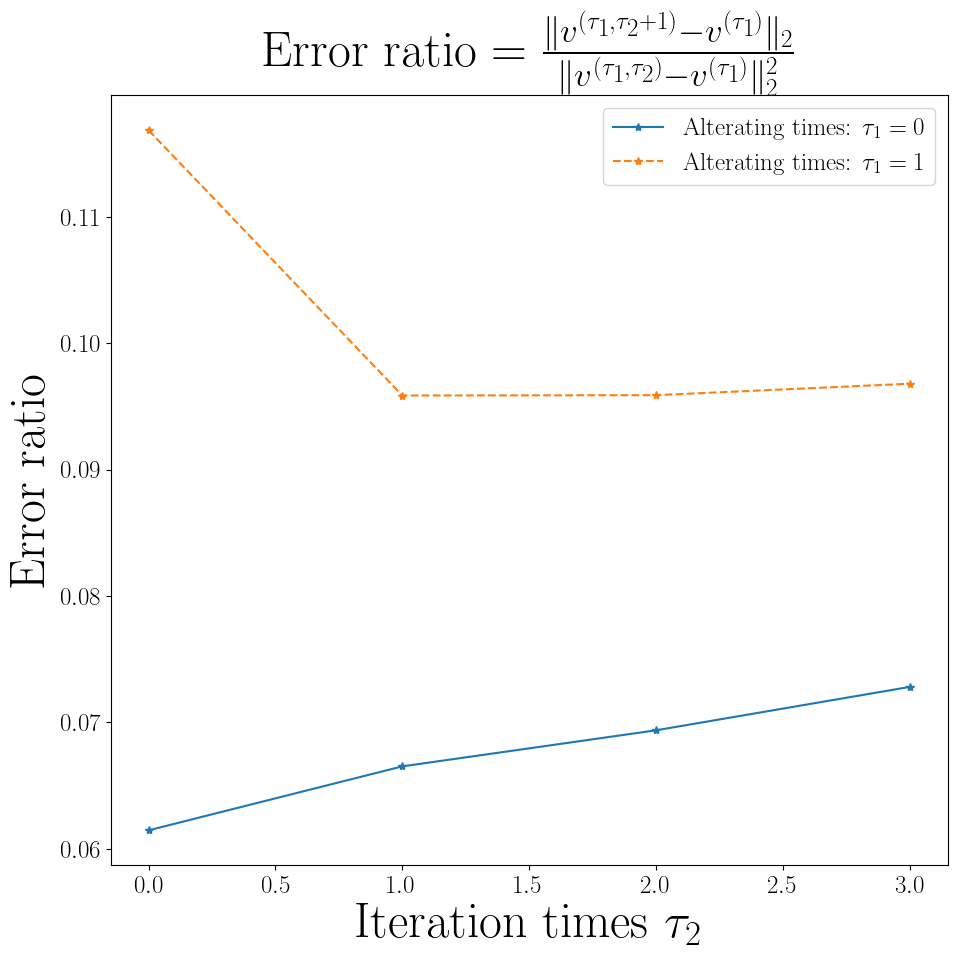

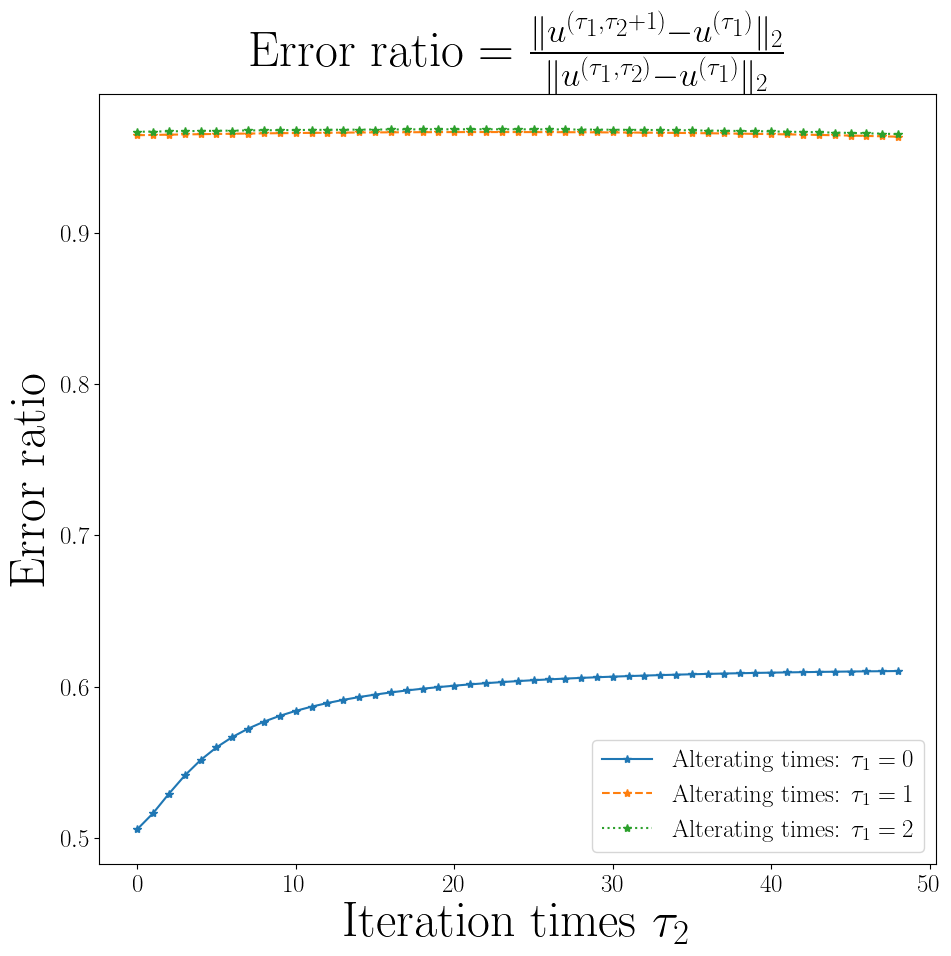

In [ ]:
T = ['-*','--*',':*',':']
rc('text', usetex=True)
rc('font', family='serif')
sz = 36
title_u = r'Error ratio $ = \frac{\|u^{(\tau_1,\tau_2+1)}-u^{(\tau_1)}\|_2}{\|u^{(\tau_1,\tau_2)}-u^{(\tau_1)}\|_2}$'
title_v = r'Error ratio $ = \frac{\|v^{(\tau_1,\tau_2+1)}-v^{(\tau_1)}\|_2}{\|v^{(\tau_1,\tau_2)}-v^{(\tau_1)}\|^2_2}$'
ylabel = 'Error ratio'
xlabel = r'Iteration times $\tau_2$'
t_u = 50
t_v = 5

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz/2)
plt.yticks(size=sz/2)
plt.title(title_v,size =sz)
for i,V in enumerate(VV[:2]):
    v = V[:t_v]
    ax.plot(range(len(v)-1)+1,np.array(v[1:])/(np.array(v[:-1]))**2,T[i+1],label = fr"Alterating times: $\tau_1 = {i}$",)
    #ax.plot(-np.log(V[:-1]),-np.log(V[1:])+np.log(V[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
    ax.set_ylabel(ylabel,size = sz)

x = np.linspace(0,5,500)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_v.pdf')

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz/2)
plt.yticks(size=sz/2)
plt.title(title_u,size =sz)

for i,U in enumerate(UU):
    u = U[:t_u]
    ax.plot(range(len(u)-1)+1,np.array(u[1:])/np.array(u[:-1]),T[i+1],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
    ax.set_ylabel(ylabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_u.pdf')

plt.show()

### Does covariate fully capture the score?（simulation）

Set $\rm num\in\{10,15,20\}$

In [2]:
num = 15 #{10,15,20}

n = 2000
d = 4
v = np.array([(i+1)/d for i in range(d)])
X = np.random.normal(0,1,(n,d))
p = algorithm.s(X@v)
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'
file_name = 'inference test'
file_name_1 = 'DS'
file_name_2 = 'Dp-v'

In [3]:
repeat_times = 100000
tasks = [delayed(algorithm.test_statistics)(X,d,num,v) for _ in range(repeat_times)]
results = Parallel(n_jobs=10)(tasks)
results = np.array(results)
with open(save_data_path+file_name+f'({num},{n}).txt','a') as file:
    for r in results:
        for rr in r:
            file.write(f'{str(rr)},')
        file.write('\n')

Distribution of statistic

In [4]:
statistics,p_value = [],[]
with open(save_data_path+file_name+f'({num},{n}).txt','r') as file:
    for line in file:
        temp = line.split(',')
        statistics.append(float(temp[0]))
        p_value.append(float(temp[1]))
  
np.mean(statistics), np.std(statistics)**2/2

(14.018507627599778, 14.035354402144408)

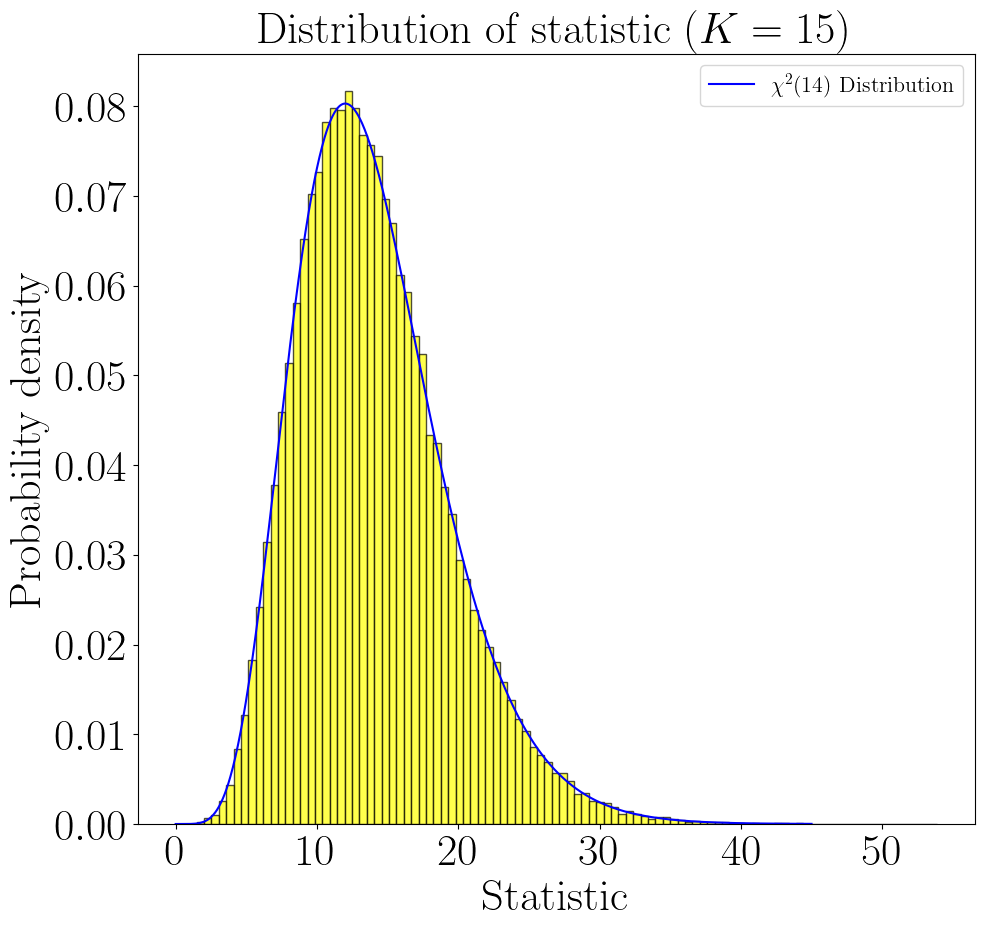

In [5]:
plt.figure(figsize=(10.8, 10))
x = np.linspace(0,3*num, 1000)
pdf = chi2.pdf(x, num-1)
plt.hist(statistics, bins=100, alpha=0.7, color='yellow', edgecolor='black',density = True)
plt.plot(x, pdf, label=fr'$\chi^2({num-1})$ Distribution', color='blue')
plt.title(fr"Distribution of statistic ($K={num}$)",size =sz)
plt.xlabel('Statistic',size =sz)
plt.ylabel('Probability density',size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+file_name_1+f'({num}).pdf')

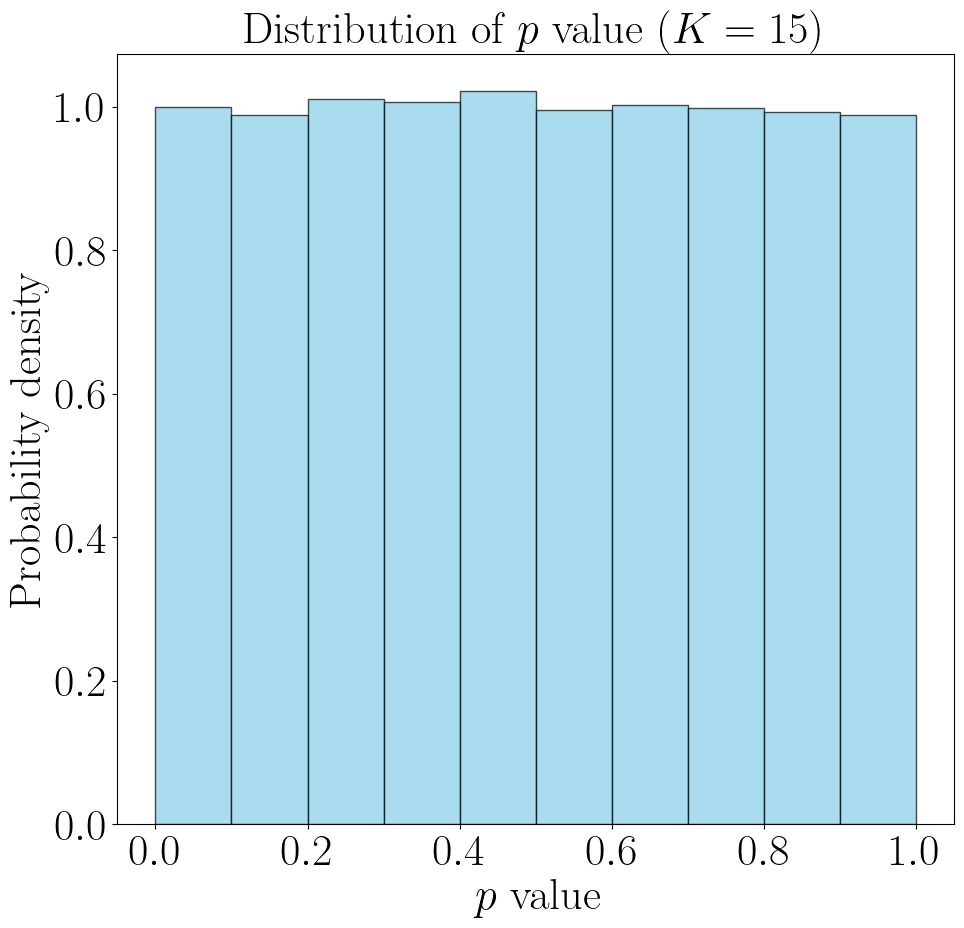

In [6]:
plt.figure(figsize=(10.8, 10))
plt.hist(p_value, bins=10, alpha=0.7, color='skyblue', edgecolor='black',density = True)
plt.title(fr"Distribution of $p$ value ($K={num}$)",size =sz)
plt.xlabel(r'$p$ value',size=sz)
plt.ylabel('Probability density',size=sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.savefig(save_path+file_name_2+f'({num}).pdf')